<div style="background: linear-gradient(135deg, #880e4f 0%, #ad1457 50%, #c2185b 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">Зертханалық Жұмыс 1</h1>
  <h2 style="color:#f8bbd0; font-size:1.4em; font-weight:400; margin:0 0 16px 0;">Коллаборативті Фильтрация</h2>
  <p style="color:#fce4ec; font-size:1em; margin:0;">User-CF · Item-CF · Pearson · Косинус · k-NN · Сиректік · Суық Іске Қосу · Матрица Визуализациясы</p>
</div>

## Кіріспе

**Коллаборативті фильтрация** (CF) — ұсыныс жүйесінің ең классикалық тəсілі. «Collaborative» дегені — басқа пайдаланушылардың тəжірибесін бірлесіп пайдалану. Өнім мазмұны туралы ақпарат мүлдем керек емес.

Бұл зертханада MovieLens стиліндегі деректерде CF-тің əртүрлі нұсқаларын тереңірек зерттейсіз: ұқсастық метрикаларын салыстырасыз, k санының əсерін байқайсыз, сиректік пен суық іске қосу мəселесін талдайсыз.

## Оқу Мақсаттары

- Косинус, Pearson жəне жатқызылған косинус ұқсастықтарын есептеп салыстыра аласыз
- k-NN гиперпараметрінің ұсыныс сапасына əсерін байқайсыз
- Сиректік (sparsity) проблемасын деректерде өлшей аласыз
- Суық іске қосу (cold start) мəселесін анықтап, оны шешу тəсілдерін сипаттай аласыз
- Leave-One-Out кросс-валидациясымен CF нəтижесін бағалай аласыз

**Болжалды орындалу уақыты: 20 минут**

## 1-бөлім: Кітапханаларды Импорттау

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

def cosine_similarity(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    X_norm = X / norms
    return X_norm @ X_norm.T

print("Кітапханалар жүктелді.")


Кітапханалар жүктелді.


## 2-бөлім: Деректерді Дайындау — MovieLens Стилінде

In [2]:
# MovieLens Mini деректер жинағын имитациялаймыз
N_USERS  = 200
N_ITEMS  = 300
N_GENRES = 5

# Пайдаланушы профильдері: əр пайдаланушы белгілі жанрларды ұнатады
user_genre_prefs = np.random.dirichlet(np.ones(N_GENRES), N_USERS)
item_genres      = np.random.dirichlet(np.ones(N_GENRES), N_ITEMS)

# Нақты ұнату = пайдаланушы жəне өнім профильдерінің ұқсастығы
true_affinity = user_genre_prefs @ item_genres.T  # (N_USERS, N_ITEMS)
true_affinity = 1 + 4 * (true_affinity - true_affinity.min()) / (
    true_affinity.max() - true_affinity.min()
)

# Сирек рейтинг матрицасын жасаймыз
DENSITY  = 0.05   # 5% — нақты MovieLens-ке жақын
obs_mask = np.random.binomial(1, DENSITY, (N_USERS, N_ITEMS)).astype(bool)
R = np.where(obs_mask, true_affinity + np.random.randn(N_USERS, N_ITEMS)*0.3, 0.0)
R = np.clip(R, 0, 5) * obs_mask

print(f"Пайдаланушы: {N_USERS}, Өнімдер: {N_ITEMS}")
print(f"Бақыланатын рейтинг: {obs_mask.sum()} / {N_USERS*N_ITEMS} = {obs_mask.mean():.2%}")

Пайдаланушы: 200, Өнімдер: 300
Бақыланатын рейтинг: 2961 / 60000 = 4.93%


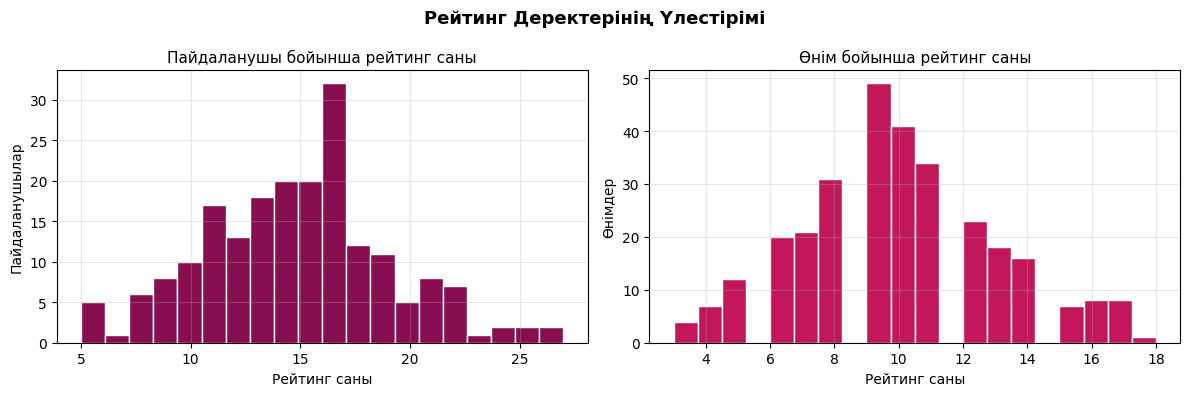

Ең аз бағаланған пайдаланушы: #167 (5 рейтинг)
Ең аз бағаланған өнім:        #37 (3 рейтинг)


In [3]:
user_counts = (R > 0).sum(axis=1)
item_counts = (R > 0).sum(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Рейтинг Деректерінің Үлестірімі', fontsize=13, fontweight='bold')

ax1.hist(user_counts, bins=20, color='#880e4f', edgecolor='white')
ax1.set_title('Пайдаланушы бойынша рейтинг саны', fontsize=11)
ax1.set_xlabel('Рейтинг саны')
ax1.set_ylabel('Пайдаланушылар')
ax1.grid(True, alpha=0.3)

ax2.hist(item_counts, bins=20, color='#c2185b', edgecolor='white')
ax2.set_title('Өнім бойынша рейтинг саны', fontsize=11)
ax2.set_xlabel('Рейтинг саны')
ax2.set_ylabel('Өнімдер')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Ең аз бағаланған пайдаланушы: #{np.argmin(user_counts)} ({user_counts.min()} рейтинг)")
print(f"Ең аз бағаланған өнім:        #{np.argmin(item_counts)} ({item_counts.min()} рейтинг)")


## 3-бөлім: Ұқсастық Метрикалары

CF-те пайдаланушы немесе өнім ұқсастығын өлшеудің бірнеше жолы бар:

In [4]:
def cosine_sim_sparse(R):
    """Косинустық ұқсастық — нөлдік мəндерді ескермейді."""
    return cosine_similarity(R)

def pearson_sim(R):
    """
    Pearson корреляция ұқсастығы.
    Əр пайдаланушының орташа рейтингін шегеріп қолданады —
    рейтинг ауқымын теңестіреді.
    """
    n_users = R.shape[0]
    sim     = np.zeros((n_users, n_users))
    for u in range(n_users):
        for v in range(u, n_users):
            # Екеуі де бағалаған ортақ өнімдер
            common = (R[u] > 0) & (R[v] > 0)
            if common.sum() < 2:
                sim[u, v] = sim[v, u] = 0.0
                continue
            ru = R[u, common] - R[u, common].mean()
            rv = R[v, common] - R[v, common].mean()
            num = (ru * rv).sum()
            den = (np.sqrt((ru**2).sum()) * np.sqrt((rv**2).sum()) + 1e-10)
            sim[u, v] = sim[v, u] = num / den
    return sim

def adjusted_cosine_sim(R):
    """
    Жатқызылған косинустық ұқсастық (item-based үшін).
    Əр пайдаланушының орташа рейтингін шегереміз.
    """
    # Пайдаланушы орташа рейтинглерін шегеру
    user_means = np.where(R > 0, R, np.nan)
    user_means = np.nanmean(user_means, axis=1, keepdims=True)
    R_adj      = np.where(R > 0, R - user_means, 0.0)
    return cosine_similarity(R_adj.T)

print("Ұқсастық функциялары анықталды.")

Ұқсастық функциялары анықталды.


Ұқсастық матрицалары есептелуде...
Аяқталды.


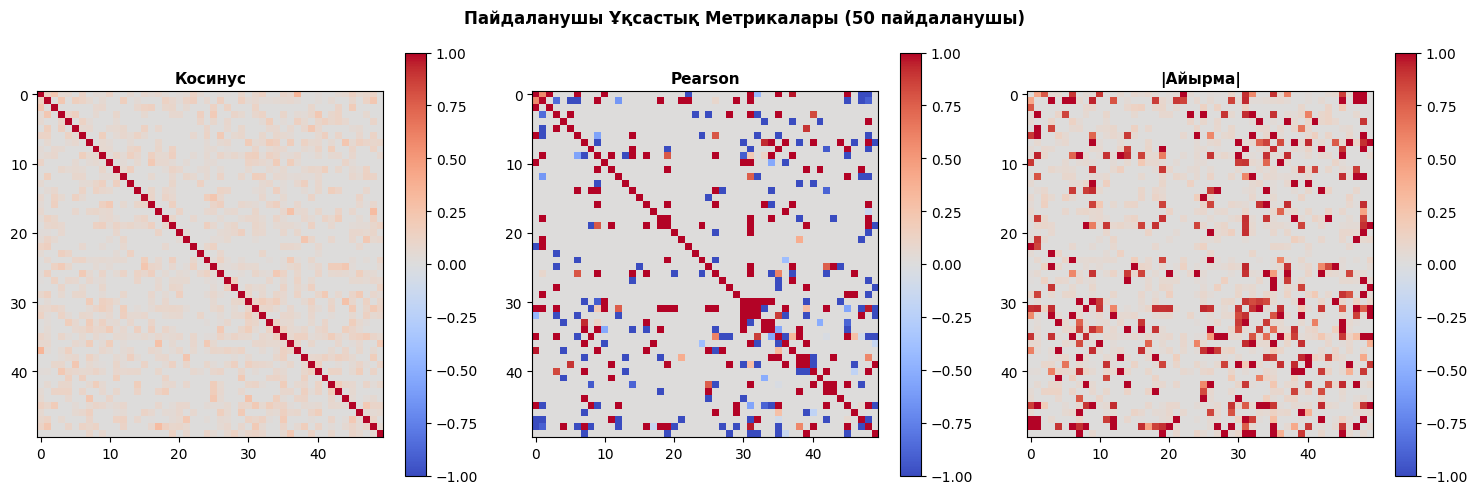

Орташа |айырма|: 0.1633


In [5]:
print("Ұқсастық матрицалары есептелуде...")
R_sub = R[:50]

cos_sim = cosine_sim_sparse(R_sub)
pear_sim = pearson_sim(R_sub)
print("Аяқталды.")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Пайдаланушы Ұқсастық Метрикалары (50 пайдаланушы)',
             fontsize=12, fontweight='bold')

for ax, mat, title in zip(
    [ax1, ax2, ax3],
    [cos_sim, pear_sim, np.abs(cos_sim - pear_sim)],
    ['Косинус', 'Pearson', '|Айырма|']
):
    im = ax.imshow(mat, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Орташа |айырма|: {np.mean(np.abs(cos_sim - pear_sim)):.4f}")


## 4-бөлім: k-NN Гиперпараметрінің Əсері

In [6]:
def cf_predict(R, user_idx, item_idx, sim_matrix, k=10, mode='user'):
    """
    CF болжамы: пайдаланушы немесе өнім-негізді.
    mode: 'user' немесе 'item'
    """
    if mode == 'user':
        sims      = sim_matrix[user_idx].copy()
        sims[user_idx] = -1
        neighbors = np.argsort(sims)[::-1][:k]
        weights   = sims[neighbors]
        ratings   = R[neighbors, item_idx]
    else:  # item
        sims      = sim_matrix[item_idx].copy()
        sims[item_idx] = -1
        neighbors = np.argsort(sims)[::-1][:k]
        weights   = sims[neighbors]
        ratings   = R[user_idx, neighbors]

    rated_mask = ratings > 0
    if rated_mask.sum() == 0:
        return 0.0
    return (
        np.dot(weights[rated_mask], ratings[rated_mask])
        / (np.abs(weights[rated_mask]).sum() + 1e-10)
    )

print("cf_predict() анықталды.")

cf_predict() анықталды.


In [7]:
k_values = [1, 3, 5, 10, 20, 30, 50]
rmse_user = []
rmse_item = []

user_sim_full = cosine_sim_sparse(R)
item_sim_full = adjusted_cosine_sim(R)

test_pairs = [
    (u, i)
    for u in range(30)
    for i in np.where(R[u] > 0)[0]
]

for k in k_values:
    errs_u, errs_i = [], []
    for u, i in test_pairs:
        true_r = R[u, i]
        R_loo = R.copy()
        R_loo[u, i] = 0

        pred_u = cf_predict(R_loo, u, i, user_sim_full, k=k, mode='user')
        pred_i = cf_predict(R_loo, u, i, item_sim_full, k=k, mode='item')
        errs_u.append((true_r - pred_u) ** 2)
        errs_i.append((true_r - pred_i) ** 2)

    rmse_user.append(np.sqrt(np.mean(errs_u)))
    rmse_item.append(np.sqrt(np.mean(errs_i)))
    print(f"k={k:>3}: User-CF RMSE={rmse_user[-1]:.4f}, Item-CF RMSE={rmse_item[-1]:.4f}")

best_k_user = k_values[np.argmin(rmse_user)]
best_k_item = k_values[np.argmin(rmse_item)]
print(f"\nҮздік k (User-CF): {best_k_user}")
print(f"Үздік k (Item-CF): {best_k_item}")


k=  1: User-CF RMSE=2.0222, Item-CF RMSE=2.1141
k=  3: User-CF RMSE=1.6067, Item-CF RMSE=1.9141
k=  5: User-CF RMSE=1.4163, Item-CF RMSE=1.6848
k= 10: User-CF RMSE=1.1131, Item-CF RMSE=1.4013
k= 20: User-CF RMSE=0.7071, Item-CF RMSE=0.9324
k= 30: User-CF RMSE=0.6134, Item-CF RMSE=0.6719
k= 50: User-CF RMSE=0.6048, Item-CF RMSE=0.3550

Үздік k (User-CF): 50
Үздік k (Item-CF): 50


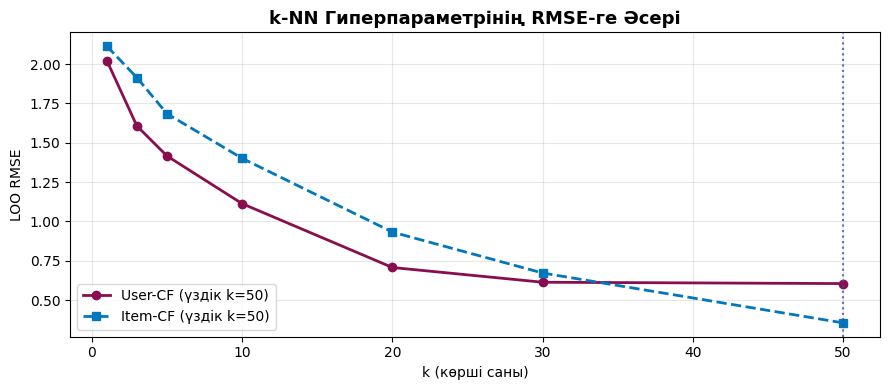

In [8]:
plt.figure(figsize=(9, 4))
plt.plot(k_values, rmse_user, 'o-', linewidth=2, color='#880e4f',
         label=f'User-CF (үздік k={best_k_user})')
plt.plot(k_values, rmse_item, 's-', linewidth=2, color='#0277bd',
         label=f'Item-CF (үздік k={best_k_item})', linestyle='--')
plt.axvline(x=best_k_user, color='#880e4f', linestyle=':', alpha=0.5)
plt.axvline(x=best_k_item, color='#0277bd',  linestyle=':', alpha=0.5)
plt.title('k-NN Гиперпараметрінің RMSE-ге Əсері', fontsize=13, fontweight='bold')
plt.xlabel('k (көрші саны)')
plt.ylabel('LOO RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5-бөлім: Сиректік Мəселесі

**Сиректік** (Sparsity) — нақты ұсыныс жүйелерінің бас ауруы. Netflix-те 500 000+ фильм бар, бірақ əрбір пайдаланушы олардың 0.01%-ін ғана бағалайды.

Тығыздық 1%: тест жұптары=72, RMSE=0.9599
Тығыздық 2%: тест жұптары=141, RMSE=1.0072
Тығыздық 5%: тест жұптары=303, RMSE=0.9691
Тығыздық 10%: тест жұптары=603, RMSE=0.8350
Тығыздық 20%: тест жұптары=1246, RMSE=0.6856


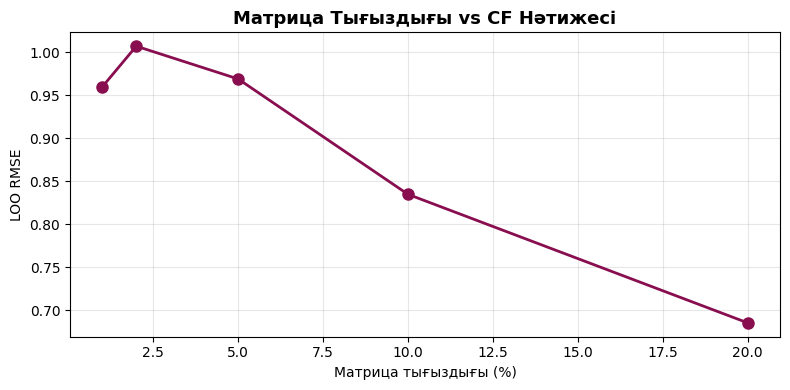

In [9]:
densities = [0.01, 0.02, 0.05, 0.10, 0.20]
rmse_sparse = []

for d in densities:
    mask_d = np.random.binomial(1, d, (N_USERS, N_ITEMS)).astype(bool)
    R_d = np.where(mask_d, true_affinity + np.random.randn(N_USERS, N_ITEMS) * 0.3, 0.0)
    R_d = np.clip(R_d, 0, 5) * mask_d

    sim_d = cosine_sim_sparse(R_d)
    pairs_d = [(u, i) for u in range(20) for i in np.where(R_d[u] > 0)[0]]

    errs = []
    for u, i in pairs_d:
        true_r = R_d[u, i]
        R_loo = R_d.copy()
        R_loo[u, i] = 0
        pred = cf_predict(R_loo, u, i, sim_d, k=10, mode='user')
        errs.append((true_r - pred) ** 2)

    rmse = np.sqrt(np.mean(errs)) if errs else np.nan
    rmse_sparse.append(rmse)
    print(f"Тығыздық {d:.0%}: тест жұптары={len(pairs_d)}, RMSE={rmse:.4f}")

plt.figure(figsize=(8, 4))
plt.plot([d * 100 for d in densities], rmse_sparse, 'o-',
         linewidth=2, color='#880e4f', markersize=8)
plt.title('Матрица Тығыздығы vs CF Нəтижесі', fontsize=13, fontweight='bold')
plt.xlabel('Матрица тығыздығы (%)')
plt.ylabel('LOO RMSE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6-бөлім: Суық Іске Қосу Мəселесі

**Cold Start** — жаңа пайдаланушы немесе жаңа өнім үшін CF жұмыс жасамайды: рейтинг жоқ → ұқсастық есептеу мүмкін емес.

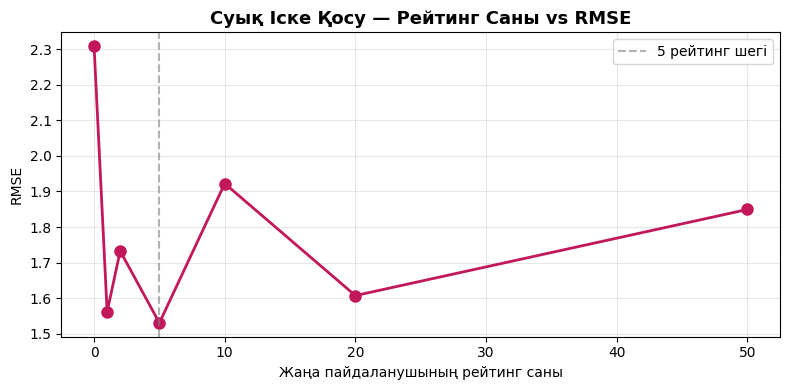

0 рейтинг кезінде RMSE: 2.3082
50 рейтинг кезінде RMSE: 1.8495


In [10]:
def simulate_cold_start(n_ratings_list, true_affinity, R_existing,
                        user_idx=0, n_test=20):
    rmse_list = []
    all_items = np.arange(N_ITEMS)

    for n_r in n_ratings_list:
        rated_items = np.random.choice(all_items, n_r, replace=False)
        new_user = np.zeros(N_ITEMS)
        new_user[rated_items] = true_affinity[user_idx, rated_items]

        R_aug = np.vstack([R_existing, new_user])
        sim_aug = cosine_sim_sparse(R_aug)
        new_uid = R_aug.shape[0] - 1

        candidates = np.where(new_user == 0)[0]
        test_items = np.random.choice(candidates, min(n_test, len(candidates)), replace=False)

        errs = []
        for i in test_items:
            pred = cf_predict(R_aug, new_uid, i, sim_aug, k=10, mode='user')
            errs.append((true_affinity[user_idx, i] - pred) ** 2)

        rmse_list.append(np.sqrt(np.mean(errs)) if errs else np.nan)

    return rmse_list

n_ratings_list = [0, 1, 2, 5, 10, 20, 50]
cold_rmse = simulate_cold_start(n_ratings_list, true_affinity, R)

plt.figure(figsize=(8, 4))
plt.plot(n_ratings_list, cold_rmse, 'o-', linewidth=2,
         color='#c2185b', markersize=8)
plt.axvline(x=5, color='gray', linestyle='--', alpha=0.6, label='5 рейтинг шегі')
plt.title('Суық Іске Қосу — Рейтинг Саны vs RMSE', fontsize=13, fontweight='bold')
plt.xlabel('Жаңа пайдаланушының рейтинг саны')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"0 рейтинг кезінде RMSE: {cold_rmse[0]:.4f}")
print(f"50 рейтинг кезінде RMSE: {cold_rmse[-1]:.4f}")


## 7-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** Косинус жəне Pearson ұқсастықтарының нəтижесі неліктен əртүрлі болады? Pearson-дың артықшылығы неде?

Косинус ұқсастығы рейтингтердің бағытын салыстырады, бірақ пайдаланушының жалпы жоғары немесе төмен бағалау әдетін толық ескермейді. Pearson әр пайдаланушының орташа рейтингін шегереді, сондықтан "қатал" және "жомарт" пайдаланушыларды әділірек салыстырады.

**Сұрақ 2.** k-NN графигінде k артқан сайын RMSE əрдайым азая ма? Неге оңтайлы k бар?

RMSE әрдайым азая бермейді. k өте аз болса, болжам тұрақсыз болады, ал k өте үлкен болса, ұқсастығы төмен пайдаланушылар да есепке кіріп, сапаны төмендетеді. Сондықтан ортада оңтайлы k мәні болады.

**Сұрақ 3.** Матрица тығыздығы 1%-ке дейін азайса CF нəтижесіне қалай əсер етеді? Бұл жағдайда қандай балама тəсіл қолданылады?

Тығыздық азайса, ортақ бағаланған өнімдер аз болады, ұқсастықты есептеу қиындайды және RMSE нашарлайды. Мұндай жағдайда content-based filtering, matrix factorization немесе hybrid recommendation тәсілдерін қолдануға болады.

**Сұрақ 4.** Суық іске қосу мəселесін шешудің 3 практикалық тəсілін атаңыз.

Бірінші тәсіл — жаңа пайдаланушыдан бастапқыда бірнеше жанр немесе өнім бойынша қызығушылығын сұрау. Екінші тәсіл — танымал өнімдерді ұсыну. Үшінші тәсіл — өнімнің жанры, сипаттамасы немесе пайдаланушы профилі сияқты қосымша контент ақпаратын қолдану.


## Қорытынды

Осы зертханада сіз MovieLens стиліндегі синтетикалық деректер жасадыңыз, косинус, Pearson жəне жатқызылған косинус ұқсастықтарын салыстырдыңыз, k-NN гиперпараметрін LOO кросс-валидациямен оңтайландырдыңыз, матрица тығыздығының CF сапасына əсерін байқадыңыз, жəне суық іске қосу мəселесін рейтинг саны vs RMSE эксперименті арқылы зерттедіңіз.

<div style="background-color:#fce4ec; border-left:5px solid #c2185b; padding:12px 16px; border-radius:6px; margin-top:16px;">
<strong>Келесі қадам:</strong> Зертханалық Жұмыс 2 — ALS: Matrix Factorization жəне латентті факторлар.
</div>